<a href="https://colab.research.google.com/github/Saiful-2/notebooks/blob/main/HR_retention_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# # EMPLOYEE RETENTION PREDICTION USING LOGISTIC REGRESSION
# Dataset: HR_comma_sep.csv

In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [2]:
# ============================================================
# STEP 2: LOAD THE DATASET
# ============================================================

# Load dataset from GitHub link

df = pd.read_csv(
    "https://raw.githubusercontent.com/Saiful-2/datasets/main/HR_comma_sep.csv"
)

In [3]:
# Display first 5 rows

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# ============================================================
# STEP 3: UNDERSTAND THE DATASET
# ============================================================

# Check total rows and columns

df.shape

(14999, 10)

In [5]:
# ============================================================
# Check column names
# ============================================================

df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# ============================================================
# Check dataset information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
# ============================================================
# Check missing values
# ============================================================

df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [8]:
# ============================================================
# STEP 4: UNDERSTAND TARGET VARIABLE
# ============================================================

# left = 1  -> Employee left company
# left = 0  -> Employee stayed in company

df['left'].value_counts()

,count
left,
0,11428
1,3571


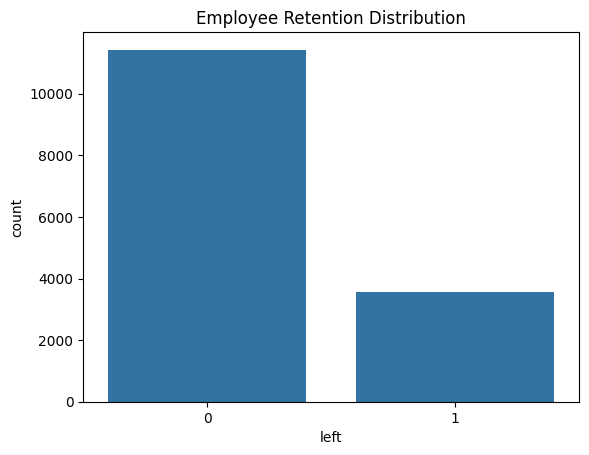

In [9]:
# ============================================================
# Visualize employee retention distribution
# ============================================================

sns.countplot(x='left', data=df)

plt.title("Employee Retention Distribution")

plt.show()

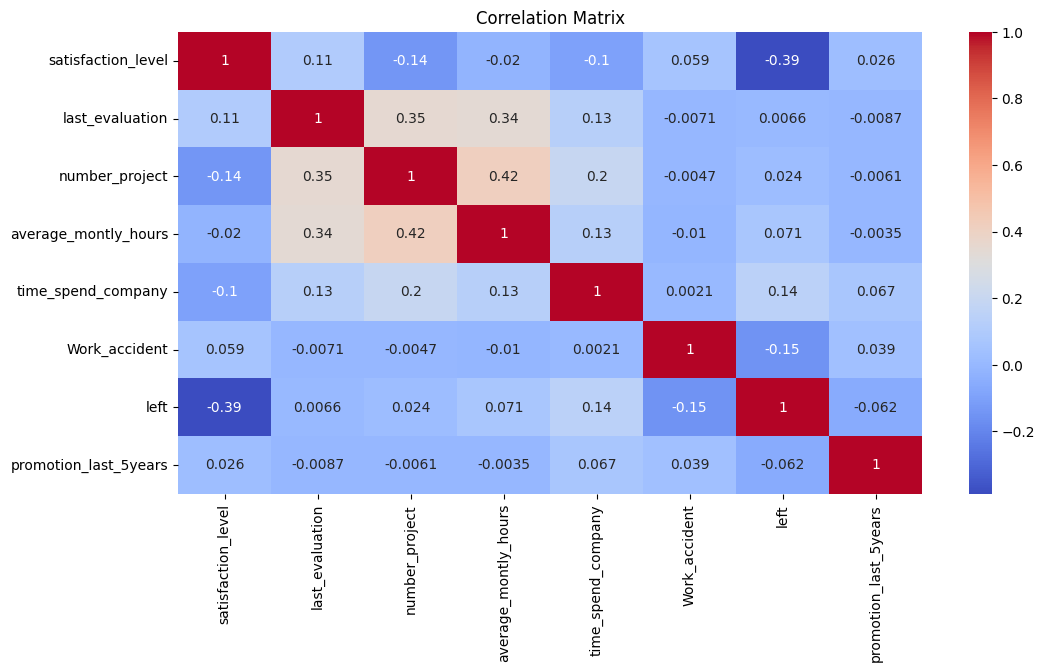

In [10]:
# ============================================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# ============================================================
# Find correlation among numerical variables
# ============================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# **Observation from correlation**:
1. satisfaction_level has strong negative relation with left
2. time_spend_company has positive relation with left
3. Work_accident has negative relation with left
4. promotion_last_5years has negative relation with left

In [11]:
# ============================================================
# STEP 6: IMPACT OF SALARY ON EMPLOYEE RETENTION
# ============================================================

salary_retention = pd.crosstab(
    df.salary,
    df.left
)

salary_retention

left,0,1
salary,,
high,1155,82
low,5144,2172
medium,5129,1317


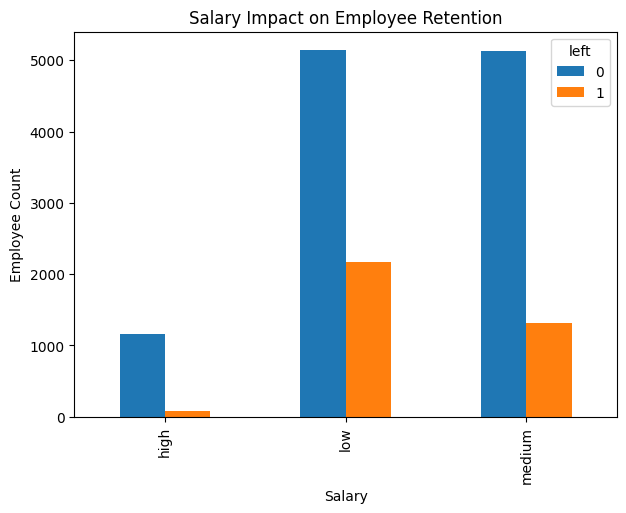

In [12]:
# ============================================================
# Plot salary vs retention
# ============================================================

salary_retention.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Salary Impact on Employee Retention")

plt.xlabel("Salary")

plt.ylabel("Employee Count")

plt.show()

# Observation:
- Employees with low salary leave more frequently.
- Employees with high salary tend to stay more.

In [13]:
# ============================================================
# STEP 7: IMPACT OF DEPARTMENT ON EMPLOYEE RETENTION
# ============================================================

department_retention = pd.crosstab(
    df.Department,
    df.left
)

department_retention

left,0,1
Department,,
IT,954,273
RandD,666,121
accounting,563,204
hr,524,215
management,539,91
marketing,655,203
product_mng,704,198
sales,3126,1014
support,1674,555


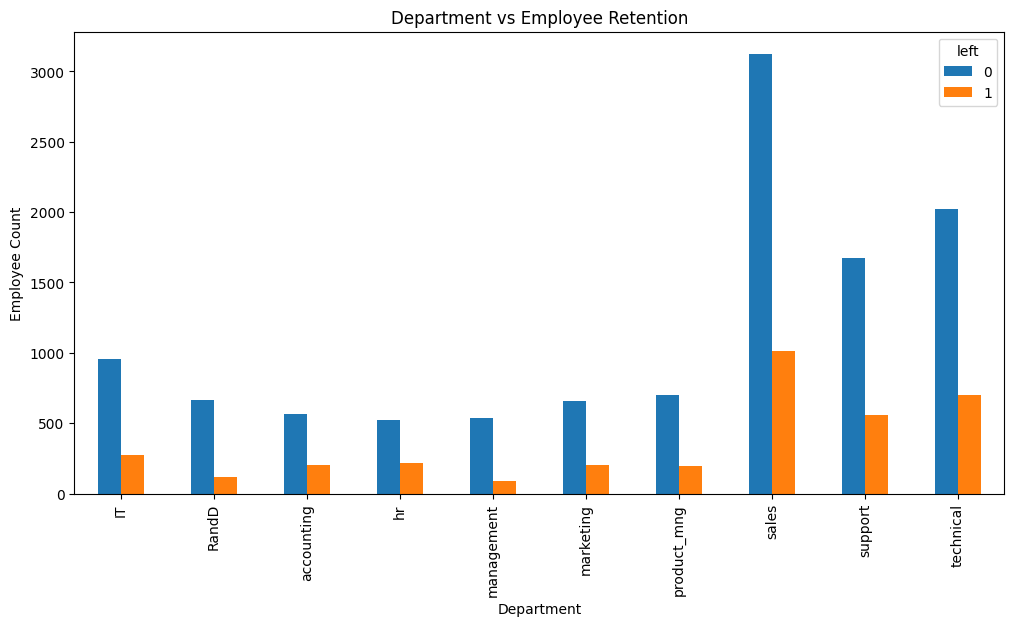

In [14]:
# ============================================================
# Plot department vs retention
# ============================================================

department_retention.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Department vs Employee Retention")

plt.xlabel("Department")

plt.ylabel("Employee Count")

plt.show()

# Observation:
- Some departments have higher employee leaving rate.
- Department also affects employee retention.

In [15]:
# ============================================================
# STEP 8: SELECT IMPORTANT FEATURES
# ============================================================

# From EDA we selected these important variables:
#
# 1. satisfaction_level
# 2. time_spend_company
# 3. Work_accident
# 4. promotion_last_5years
# 5. salary

selected_features = [
    'satisfaction_level',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years',
    'salary'
]

In [16]:
# ============================================================
# STEP 9: CONVERT CATEGORICAL VARIABLE INTO NUMERIC
# ============================================================

# salary column is categorical
# Logistic Regression requires numerical data

le = LabelEncoder()

df['salary'] = le.fit_transform(df['salary'])


# ============================================================
# Check encoded salary values
# ============================================================

df['salary'].unique()


# ============================================================
# Usually encoding becomes:
#
# high   -> 0
# low    -> 1
# medium -> 2

array([1, 2, 0])

In [17]:
# ============================================================
# STEP 10: DEFINE INPUT FEATURES (X) AND TARGET VARIABLE (y)
# ============================================================

X = df[
    [
        'satisfaction_level',
        'time_spend_company',
        'Work_accident',
        'promotion_last_5years',
        'salary'
    ]
]

y = df['left']


# ============================================================
# Display first 5 rows of X
# ============================================================

X.head()


# ============================================================
# Display first 5 values of y
# ============================================================

y.head()

,left
0,1
1,1
2,1
3,1
4,1


In [18]:
# ============================================================
# STEP 11: SPLIT DATA INTO TRAINING AND TESTING SET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ============================================================
# Check training and testing size
# ============================================================

print(X_train.shape)

print(X_test.shape)

(11999, 5)
(3000, 5)


In [19]:
# ============================================================
# STEP 12: CREATE LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=1000
)


# ============================================================
# Train the model
# ============================================================

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [20]:
# ============================================================
# STEP 13: MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# Display first 10 predictions
# ============================================================

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [21]:
# ============================================================
# STEP 14: MEASURE MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy =", accuracy)


# ============================================================
# Accuracy in percentage
# ============================================================

print("Accuracy Percentage =", accuracy * 100)

Model Accuracy = 0.753
Accuracy Percentage = 75.3


# FINAL CONCLUSION
- Variables with strong impact on employee retention:
 1. satisfaction_level
 2. time_spend_company
 3. Work_accident
 4. promotion_last_5years
 5. salary
 6. department

# Logistic Regression model predicts employee retention
# with around 75% accuracy.